# 05 — Modèle final : synthèse des configurations et évaluation approfondie

Ce notebook regroupe :
1. les **meilleurs modèles de chaque configuration** (P, L, canaux, horizon) ;
2. le **modèle final** (architecture retenue aux configurations 1 à 3, horizon opérationnel J+1 = 24 h) ;
3. sa comparaison aux références (persistance, moyenne 7 jours, **Ridge multi-sortie**, PatchTST univarié) avec tests de Diebold-Mariano ;
4. les graphes réel/prédit, les résidus et le **chapelet** des graines ;
5. la robustesse (courbe de bruit), la stabilité (rolling 30 jours, RMSE mensuel), la **validation croisée TimeSeriesSplit** ;
6. l'ablation « indice de capacité » ;
7. l'explicabilité (occultation, gradients intégrés, attention inter-canaux) ;
8. l'efficience, le score final et la sauvegarde `models/best_patchtst.pt`.

> **Pourquoi l'horizon final n'est-il pas choisi par le score ?** Comparer des horizons revient à comparer des tâches
> différentes : l'erreur à 1 h est mécaniquement plus faible qu'à 24 h. L'horizon est imposé par l'usage :
> la planification J+1 du dispatching. La configuration 4 décrit comment la performance évolue avec l'horizon.

In [1]:
# --- Environnement commun à tous les notebooks -------------------------------
import sys, warnings
from pathlib import Path
RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m          # module commun de l'étude (entièrement commenté)
import figures_style as fs       # charte graphique des figures de l'article
fs.appliquer()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analyse as an, json, torch
from nb05_final import cfg_depuis_nom, modele_final, graine_validation, charger_modele, ETAPES

## 1. Meilleur modèle de chaque configuration

In [2]:
jeu = m.construire_jeu()
selection = json.loads((m.DOSSIER_CACHE / "selection.json").read_text())
lignes = []
for etape in ETAPES:
    r = m.evaluer_configuration(cfg_depuis_nom(selection[etape]), jeu)
    t = m.tableau_comparatif([r]).iloc[0]
    lignes.append(dict(etape=etape, retenu=selection[etape], RMSE=t.RMSE, RMSE_std=t.RMSE_std, nRMSE=t.nRMSE,
                       R2=t.R2, degradation_bruit=t.degradation_bruit, drift_7j=t.drift_7j, inference_ms=t.inference_ms,
                       score=t.score))
meilleurs = pd.DataFrame(lignes); meilleurs.to_csv(m.DOSSIER_TABLEAUX / "meilleurs_par_configuration.csv", index=False)
meilleurs.round(4)

,etape,retenu,RMSE,RMSE_std,nRMSE,R2,degradation_bruit,drift_7j,inference_ms,score
0,config1_patch,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,0.2037,0.9739,0.0044,0.5839,2.9255,5.7561
1,config2_historique,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,0.2037,0.9739,0.0044,0.5839,2.9255,5.7561
2,config3_canaux,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,0.2037,0.9739,0.0044,0.5839,2.9255,5.7561
3,config4_horizon,PatchTST-CAX_P12_L168_H12,8.6091,0.0554,0.1942,0.9762,0.0052,0.5761,2.6194,8.1922


## 2. Modèle final et comparaison aux références

In [3]:
cfg = modele_final()
res = m.evaluer_configuration(cfg, jeu)
preds, vrai, orig = an.charger_predictions(cfg.nom())
print("Modèle final :", cfg.nom(), "|", cfg)
ridge = pd.read_csv(m.DOSSIER_CACHE / "final" / "ridge.csv")
y_ridge = np.load(m.DOSSIER_CACHE / "final" / "ridge_pred.npy")
import dataclasses
res_ci = m.evaluer_configuration(dataclasses.replace(cfg, mode_canaux="CI", futur_connu=False, porte_physique=False), jeu)
refs = {"Persistance J-1": m.reference_persistance(jeu, orig, cfg.H), "Moyenne 7 jours": m.reference_moyenne(jeu, orig, cfg.H),
        "Ridge multi-sortie": y_ridge}
lignes = [dict(modele=k, **m.metriques(vrai, v)) for k, v in refs.items()]
for r in [res_ci, res]:
    s = r["synthese"]
    lignes.append(dict(modele=r["nom"] + " (moy. 5 graines)", RMSE=s["RMSE_moy"], MAE=s["MAE_moy"], nRMSE=s["nRMSE_moy"],
                       R2=s["R2_moy"], MBE=s["MBE_moy"]))
comparaison = pd.DataFrame(lignes); comparaison.to_csv(m.DOSSIER_TABLEAUX / "comparaison_references.csv", index=False)
comparaison.round(4)

Modèle final : PatchTST-CAX_P12_L168_H24 | ConfigPatchTST(P=12, L=168, H=24, mode_canaux='CA', futur_connu=True, porte_physique=False, d_model=64, n_tetes=4, n_couches=2, d_ff=128, dropout=0.1, lr=0.001, taille_lot=128, epoques_max=25, patience=4, pas_train=1, fraction_epoque=0.2, pas_val=6)


,modele,RMSE,MAE,nRMSE,R2,MBE
0,Persistance J-1,10.3923,4.9667,0.2348,0.9653,0.0030
1,Moyenne 7 jours,10.8215,5.3064,0.2445,0.9624,-0.0260
2,Ridge multi-sortie,9.1966,4.8673,0.2078,0.9729,-0.6942
3,PatchTST-CI_P12_L168_H24 (moy. 5 graines),9.4676,5.4778,0.2139,0.9712,0.4551
4,PatchTST-CAX_P12_L168_H24 (moy. 5 graines),9.0158,5.2086,0.2037,0.9739,-0.0050


In [4]:
# Tests de Diebold-Mariano (graine représentative du modèle final contre chaque référence)
g_rep = an.graine_representative(res)
e_mod = preds[m.GRAINES.index(g_rep)] - vrai
dm = []
for k, v in refs.items():
    stat, p = m.test_diebold_mariano(e_mod, v - vrai, h=cfg.H)
    dm.append(dict(reference=k, DM=stat, p_valeur=p, skill_score=1 - np.sqrt((e_mod**2).mean()) / np.sqrt(((v - vrai)**2).mean())))
pd.DataFrame(dm).round(4)

,reference,DM,p_valeur,skill_score
0,Persistance J-1,-2.9661,0.0030,0.1314
1,Moyenne 7 jours,-3.0762,0.0021,0.1659
2,Ridge multi-sortie,-0.7995,0.4240,0.0185


## 3. Chapelet des graines, série observée vs prédite et résidus

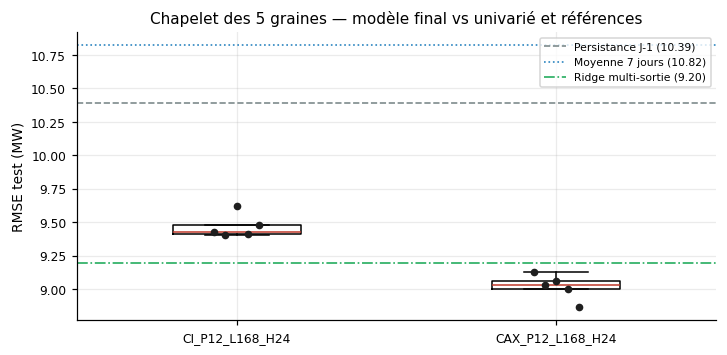

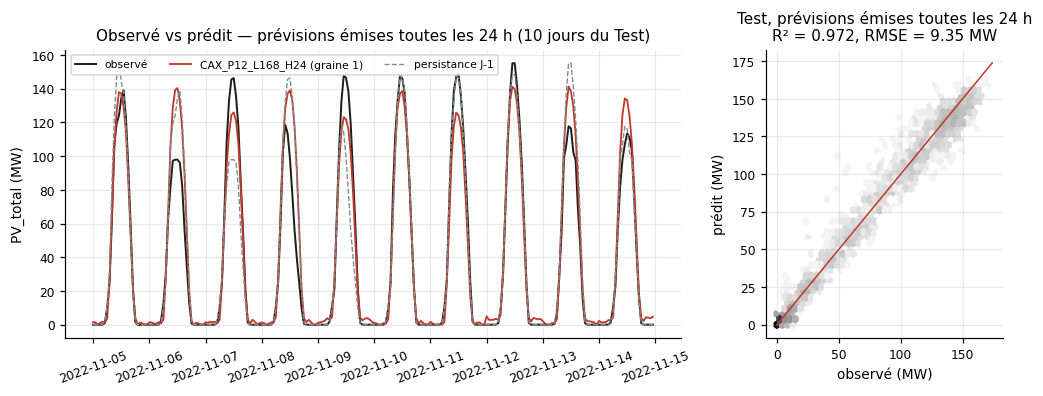

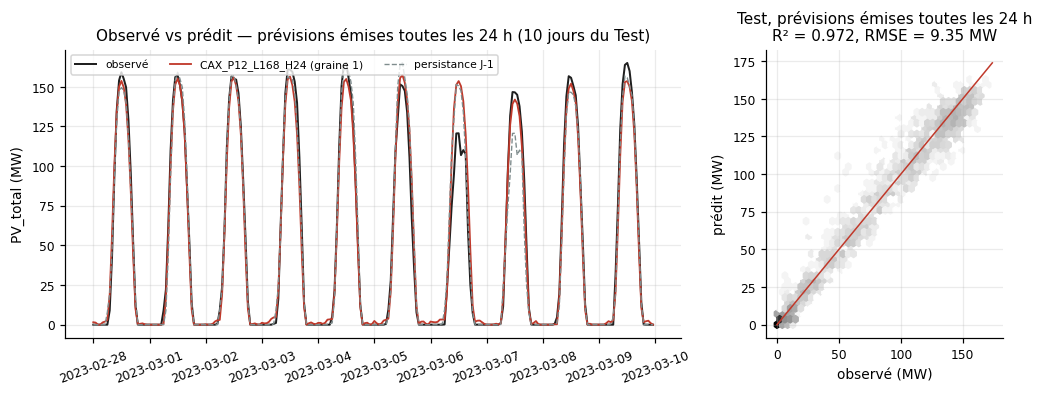

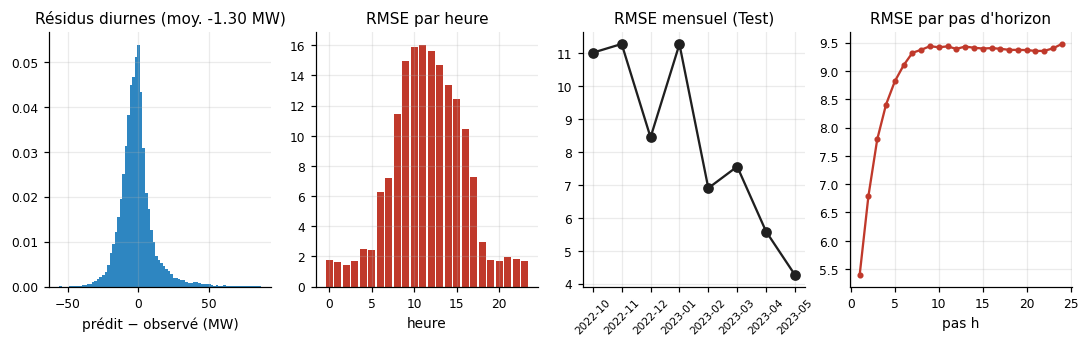

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
groupes = {an.etiquette(r["nom"]): [g["RMSE"] for g in r["par_graine"]] for r in [res_ci, res]}
ax.boxplot(list(groupes.values()), widths=0.4, showfliers=False, medianprops=dict(color=fs.COULEURS["modele"]))
for i, d in enumerate(groupes.values()):
    ax.scatter(np.full(len(d), i + 1) + np.linspace(-0.07, 0.07, len(d)), d, s=16, color=fs.COULEURS["observe"], zorder=3)
styles = {"Persistance J-1": ("--", fs.COULEURS["persistance"]), "Moyenne 7 jours": (":", fs.COULEURS["moyenne"]),
          "Ridge multi-sortie": ("-.", "#27ae60")}
for k, v in refs.items():
    r = m.metriques(vrai, v)["RMSE"]; ax.axhline(r, ls=styles[k][0], color=styles[k][1], lw=1.1, label=f"{k} ({r:.2f})")
ax.set_xticks(range(1, len(groupes) + 1), list(groupes.keys())); ax.set_ylabel("RMSE test (MW)")
ax.legend(fontsize=7, loc="upper right"); ax.set_title("Chapelet des 5 graines — modèle final vs univarié et références")
fs.sauver(fig, "fig_final_chapelet")
an.fig_observe_predit(res, jeu, "fig_final_observe_predit")
an.fig_observe_predit(res, jeu, "fig_final_observe_predit_saison_seche", jours=10, debut_jour=150)
an.fig_residus(res, jeu, "fig_final_residus")

## 4. Robustesse : dégradation en fonction du niveau de bruit sur les exogènes

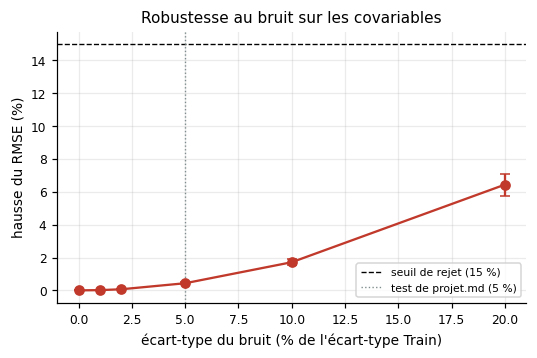

,mean,std
niveau,,
0.00,0.000,0.000
0.01,0.015,0.004
0.02,0.067,0.009
0.05,0.435,0.048
0.10,1.714,0.180
0.20,6.437,0.662


In [6]:
bruit = pd.read_csv(m.DOSSIER_CACHE / "final" / "bruit.csv")
b = bruit.groupby("niveau").degradation.agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.errorbar(100 * b.index, 100 * b["mean"], yerr=100 * b["std"], marker="o", color=fs.COULEURS["modele"], capsize=3)
ax.axhline(15, color="k", ls="--", lw=0.9, label="seuil de rejet (15 %)")
ax.axvline(5, color=fs.COULEURS["persistance"], ls=":", lw=0.9, label="test de projet.md (5 %)")
ax.set_xlabel("écart-type du bruit (% de l'écart-type Train)"); ax.set_ylabel("hausse du RMSE (%)"); ax.legend(fontsize=7)
ax.set_title("Robustesse au bruit sur les covariables")
fs.sauver(fig, "fig_final_bruit")
(100 * b).round(3)

## 5. Stabilité long terme : rolling 30 jours et RMSE mensuel sur tout le Test

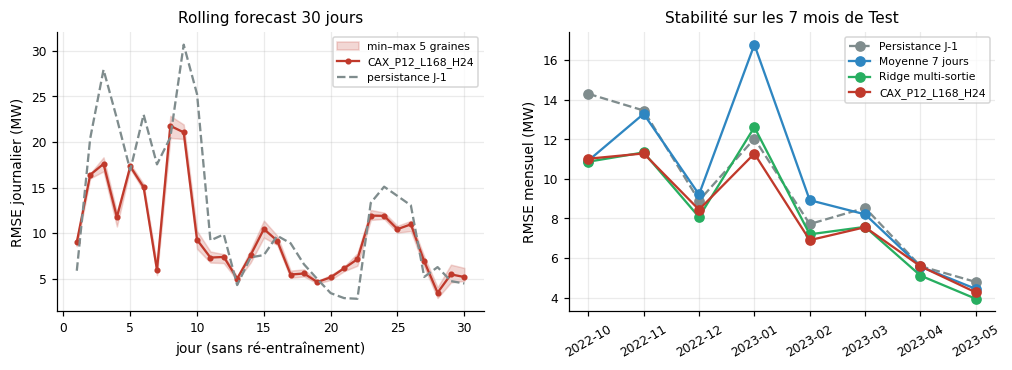

,Persistance J-1,Moyenne 7 jours,Ridge multi-sortie,CAX_P12_L168_H24
horodatage,,,,
2022-10,14.301,10.924,10.869,11.020
2022-11,13.456,13.288,11.337,11.286
2022-12,8.903,9.214,8.072,8.447
2023-01,12.030,16.783,12.614,11.279
2023-02,7.717,8.925,7.198,6.904
2023-03,8.535,8.208,7.576,7.559
2023-04,5.592,5.568,5.114,5.585
2023-05,4.791,4.440,3.942,4.264


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
rj = np.array([g["rmse_journaliers"] for g in res["par_graine"]])
k30 = orig < jeu.i_test + 24 * 30
rj_p = m.rmse_journaliers(vrai[k30], refs["Persistance J-1"][k30], orig[k30], jeu)
jours = np.arange(1, rj.shape[1] + 1)
ax[0].fill_between(jours, rj.min(0), rj.max(0), color=fs.COULEURS["modele"], alpha=0.2, label="min–max 5 graines")
ax[0].plot(jours, rj.mean(0), color=fs.COULEURS["modele"], marker=".", label=an.etiquette(cfg.nom()))
ax[0].plot(jours, rj_p.values, color=fs.COULEURS["persistance"], ls="--", label="persistance J-1")
ax[0].set_xlabel("jour (sans ré-entraînement)"); ax[0].set_ylabel("RMSE journalier (MW)"); ax[0].legend(fontsize=7)
ax[0].set_title("Rolling forecast 30 jours")
mm = {k: an.rmse_mensuel(vrai, v, orig, jeu) for k, v in refs.items()}
mm[an.etiquette(cfg.nom())] = an.rmse_mensuel(vrai, preds[m.GRAINES.index(g_rep)], orig, jeu)
couleurs = {"Persistance J-1": fs.COULEURS["persistance"], "Moyenne 7 jours": fs.COULEURS["moyenne"],
            "Ridge multi-sortie": "#27ae60", an.etiquette(cfg.nom()): fs.COULEURS["modele"]}
for k, s in mm.items():
    ax[1].plot(range(len(s)), s.values, marker="o", label=k, color=couleurs[k],
               ls="--" if k == "Persistance J-1" else "-")
ax[1].set_xticks(range(len(s)), s.index, rotation=30); ax[1].set_ylabel("RMSE mensuel (MW)"); ax[1].legend(fontsize=7)
ax[1].set_title("Stabilité sur les 7 mois de Test")
fs.sauver(fig, "fig_final_stabilite")
pd.DataFrame(mm).round(3)

## 6. Validation croisée temporelle (TimeSeriesSplit, 5 plis à fenêtre croissante)

Pour chaque pli, la normalisation est **ré-ajustée** sur la partie Train du pli (R2) ; 15 % de la fenêtre
d'apprentissage servent à l'arrêt précoce ; le bloc suivant sert de test. Les plis couvrent 2019–2023 :
on vérifie ainsi que les performances ne dépendent pas d'une période particulière.

In [8]:
cv = pd.read_csv(m.DOSSIER_CACHE / "final" / "validation_croisee.csv")
cv.to_csv(m.DOSSIER_TABLEAUX / "validation_croisee.csv", index=False)
display(cv.round(4))
print(f"Gain moyen vs persistance : {100*cv.gain_vs_persistance.mean():+.1f} % ± {100*cv.gain_vs_persistance.std():.1f} %")

,pli,train,test,RMSE,nRMSE,R2,RMSE_persistance,gain_vs_persistance,epoques
0,1,2019-01 → 2019-08,2019-09-23 → 2020-06-13,7.6732,0.2469,0.9645,7.8612,0.0239,20
1,2,2019-01 → 2020-03,2020-06-14 → 2021-03-05,10.1804,0.3341,0.9345,11.6726,0.1278,15
2,3,2019-01 → 2020-11,2021-03-06 → 2021-11-25,12.0865,0.2670,0.9540,14.4161,0.1616,25
3,4,2019-01 → 2021-06,2021-11-26 → 2022-08-17,10.8585,0.2458,0.9617,13.3488,0.1866,22
4,5,2019-01 → 2022-01,2022-08-18 → 2023-05-09,9.9412,0.2274,0.9675,12.0269,0.1734,25


Gain moyen vs persistance : +13.5 % ± 6.6 %


## 7. Ablation : « indice de capacité » causal

Variante : le modèle apprend k = PV_total / C(t), où C(t) est le quantile 99 % des maxima journaliers des 30 jours
**précédents** (capacité apparente, mise à jour causalement après chaque mise en service). La prévision est remise
en MW en multipliant par C(t). Même configuration, 5 graines.

In [9]:
kc = pd.read_csv(m.DOSSIER_CACHE / "final" / "indice_capacite.csv")
s = res["synthese"]
pd.DataFrame([dict(variante="RevIN seul (modèle final)", RMSE=s["RMSE_moy"], RMSE_std=s["RMSE_std"], drift_7j=s["drift_7j_moy"]),
              dict(variante="Indice de capacité + RevIN", RMSE=kc.RMSE.mean(), RMSE_std=kc.RMSE.std(), drift_7j=kc.drift_7j.mean())]).round(4)

,variante,RMSE,RMSE_std,drift_7j
0,RevIN seul (modèle final),9.0158,0.0974,0.5839
1,Indice de capacité + RevIN,9.0995,0.1651,0.5808


## 8. Explicabilité

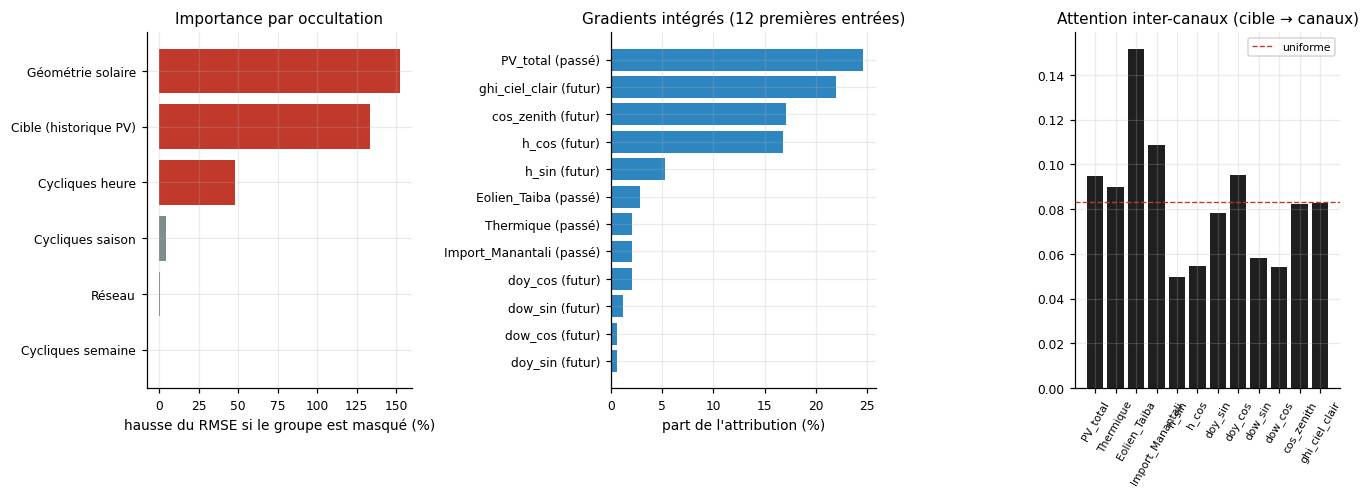

,groupe,RMSE,hausse_RMSE
0,Cible (historique PV),21.0900,1.3359
1,Réseau,9.0384,0.0011
2,Cycliques heure,13.3303,0.4765
3,Cycliques saison,9.4231,0.0437
4,Cycliques semaine,8.9871,-0.0046
5,Géométrie solaire,22.7928,1.5245


,entree,part
0,PV_total (passé),0.2462
19,ghi_ciel_clair (futur),0.2192
18,cos_zenith (futur),0.1710
13,h_cos (futur),0.1680
12,h_sin (futur),0.0527
2,Eolien_Taiba (passé),0.0289
1,Thermique (passé),0.0211
3,Import_Manantali (passé),0.0210
15,doy_cos (futur),0.0205
16,dow_sin (futur),0.0117


In [10]:
occ = pd.read_csv(m.DOSSIER_CACHE / "final" / "xai_occultation.csv")
ig = pd.read_csv(m.DOSSIER_CACHE / "final" / "xai_gradients_integres.csv")
f_att = m.DOSSIER_CACHE / "final" / "xai_attention.csv"
att = pd.read_csv(f_att) if f_att.exists() else None
fig, ax = plt.subplots(1, 3 if att is not None else 2, figsize=(14, 4.2), gridspec_kw={"wspace": 0.75})
o = occ.sort_values("hausse_RMSE")
ax[0].barh(o.groupe, 100 * o.hausse_RMSE, color=[fs.COULEURS["modele"] if v > 0.05 else fs.COULEURS["persistance"] for v in o.hausse_RMSE])
ax[0].set_xlabel("hausse du RMSE si le groupe est masqué (%)"); ax[0].set_title("Importance par occultation")
i = ig.sort_values("part").tail(12)
ax[1].barh(i.entree, 100 * i.part, color=fs.COULEURS["moyenne"]); ax[1].set_xlabel("part de l'attribution (%)")
ax[1].set_title("Gradients intégrés (12 premières entrées)")
if att is not None:
    ax[2].bar(range(len(att)), att.poids, color=fs.COULEURS["observe"]); ax[2].axhline(1 / len(att), ls="--", color=fs.COULEURS["modele"], lw=0.9, label="uniforme")
    ax[2].set_xticks(range(len(att)), att.canal, rotation=60, fontsize=7); ax[2].legend(fontsize=7)
    ax[2].set_title("Attention inter-canaux (cible → canaux)")
fs.sauver(fig, "fig_final_xai")
display(occ.round(4)); display(ig.sort_values("part", ascending=False).round(4))

## 9. Efficience, score final et sauvegarde du modèle

In [11]:
s = res["synthese"]
effi = pd.DataFrame([dict(inference_ms=s["inference_ms_moy"], taille_Mo=s["taille_Mo_moy"], n_parametres=int(s["n_parametres_moy"]),
                          duree_entrainement_s=s["duree_s_moy"], epoques=s["epoques_moy"], **m.score_decision(s))])
display(effi.round(3))
g = graine_validation(cfg)
mod = charger_modele(cfg, g)
(RACINE / "models").mkdir(exist_ok=True)
torch.save({"etat": mod.state_dict(), "config": dataclasses.asdict(cfg), "graine": g, "canaux": m.CANAUX,
            "moyenne_train": jeu.moyenne, "ecart_type_train": jeu.ecart_type,
            "decalage_solaire_h": jeu.decalage_solaire_h}, RACINE / "models" / "best_patchtst.pt")
taille = (RACINE / "models" / "best_patchtst.pt").stat().st_size / 2**20
print(f"Modèle sauvegardé : models/best_patchtst.pt (graine {g}, choisie sur la perte de validation) — {taille:.2f} Mo")
# contrôle : rechargement et prévision identique
verif = torch.load(RACINE / "models" / "best_patchtst.pt", weights_only=False)
mod2 = m.PatchTST(m.ConfigPatchTST(**verif["config"])); mod2.load_state_dict(verif["etat"]); mod2.eval()
o_ = orig[:50]
assert np.allclose(m.predire(mod, jeu, o_)[0], m.predire(mod2, jeu, o_)[0])
print("Rechargement vérifié : prévisions identiques.")

,inference_ms,taille_Mo,n_parametres,duree_entrainement_s,epoques,score,bonus,rejete_bruit
0,2.925,0.726,186625,801.029,23.0,5.756,0.2,False


Modèle sauvegardé : models/best_patchtst.pt (graine 4, choisie sur la perte de validation) — 0.73 Mo
Rechargement vérifié : prévisions identiques.


## Conclusion — modèle final `PatchTST-CAX_P12_L168_H24`

**Précision (40 %).** RMSE = 9,02 ± 0,10 MW, nRMSE = 0,204,
R² = 0,974 sur les 7 mois de Test. Références au même horizon : persistance J-1 10,39 MW
(+13,2 %), moyenne 7 jours 10,82 MW (+16,7 %),
Ridge multi-sortie 9,20 MW (+2,0 %). **L'écart avec Ridge n'est pas significatif**
(Diebold-Mariano, p = 0,42) : sans météorologie, la prévisibilité est surtout linéaire dans l'historique récent et la
géométrie solaire future, informations dont Ridge dispose aussi.

**Robustesse (30 %).** Écart-type inter-graines 0,097 MW ; dégradation sous bruit de 5 % sur les exogènes
+0,44 % (20 % de bruit : +6,44 %), très en deçà du seuil de rejet de 15 %.
Validation croisée TimeSeriesSplit (5 plis) : gain moyen vs persistance +13,5 %
(min +2,4 %, max +18,7 %).

**Stabilité long terme (30 %).** Dérive lissée sur 30 jours sans ré-entraînement = 0,58
(objectif < 1,2) ; ratio brut J30/J1 = 0,58.

**Efficience.** 2,9 ms par prévision, 0,73 Mo, 186 625 paramètres.

**Score de décision** = 5,76 (bonus d'efficience 0,2).

**Ablation « indice de capacité ».** RMSE = 9,10 ± 0,17 MW contre 9,02 MW
pour la normalisation RevIN seule, soit +0,9 %.

**Explicabilité.** Masquer l'historique de la cible augmente le RMSE de +134 %,
la géométrie solaire de +152 %, l'encodage horaire de +48 %,
le contexte réseau de +0,1 % et le jour de semaine (témoin négatif) de -0,5 %.

Le modèle livré (`models/best_patchtst.pt`) correspond à la graine 4, choisie sur la perte de **validation**.